/var/folders/gw/297tjlxd4qv8csdzfdw8ndx80000gn/T/ipykernel_16041/3410926704.py:3: DtypeWarning: Columns (0,3,4,6,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data9.csv")


<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 0 to 44
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   industry            45 non-null     object 
 1   year                45 non-null     float64
 2   unionisation        45 non-null     float64
 3   number of jobs      45 non-null     object 
 4   median wage         45 non-null     object 
 5   median wage change  37 non-null     float64
 6   mean wage           45 non-null     object 
 7   mean wage change    36 non-null     float64
 8   percentile 1        45 non-null     object 
 9   percentile 2        45 non-null     object 
 10  percentile 3        45 non-null     object 
 11  percentile 4        45 non-null     object 
 12  percentile 5        45 non-null     object 
 13  percentile 6        45 non-null     object 
 14  percentile 7        45 non-null     object 
 15  percentile 8        45 non-null     object 
 16  percentile 9   

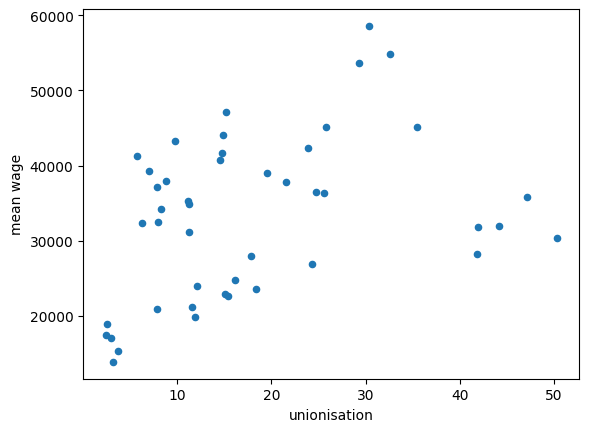

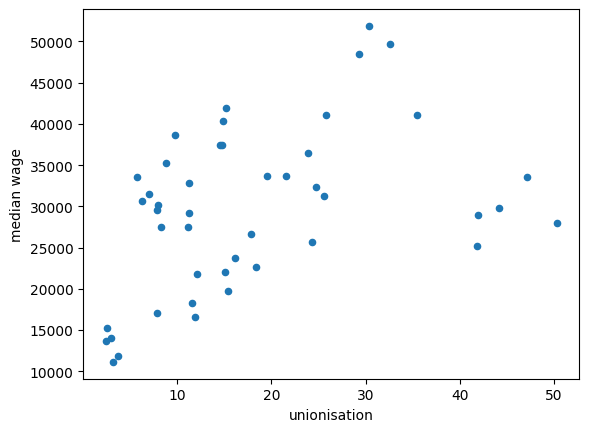

In [ ]:
import pandas as pd
#Import dataset
df = pd.read_csv("data9.csv")

df.head()

#Delete empty rows and columns
df = df.dropna(axis=0, how='all')
df = df.dropna(axis=1, how='all')


df.info()
#Data Type conversion
df["median wage"] = df["median wage"].str.replace(",", "").astype(float)
df["number of jobs"] = df["number of jobs"].str.replace(",", "").astype(int)
df["mean wage"] = df["mean wage"].str.replace(",", "").astype(float)
df["percentile 1"] = df["percentile 1"].str.replace(",", "")
df["percentile 1"] = pd.to_numeric(df["percentile 1"], errors="coerce")
df["percentile 2"] = df["percentile 2"].str.replace(",", "")
df["percentile 2"] = pd.to_numeric(df["percentile 2"], errors="coerce")
df["percentile 3"] = df["percentile 3"].str.replace(",", "")
df["percentile 3"] = pd.to_numeric(df["percentile 3"], errors="coerce")
df["percentile 4"] = df["percentile 4"].str.replace(",", "")
df["percentile 4"] = pd.to_numeric(df["percentile 4"], errors="coerce")
df["percentile 5"] = df["percentile 5"].str.replace(",", "")
df["percentile 5"] = pd.to_numeric(df["percentile 5"], errors="coerce")
df["percentile 6"] = df["percentile 6"].str.replace(",", "")
df["percentile 6"] = pd.to_numeric(df["percentile 6"], errors="coerce")
df["percentile 7"] = df["percentile 7"].str.replace(",", "")
df["percentile 7"] = pd.to_numeric(df["percentile 7"], errors="coerce")
df["percentile 8"] = df["percentile 8"].str.replace(",", "")
df["percentile 8"] = pd.to_numeric(df["percentile 8"], errors="coerce")
df["percentile 9"] = df["percentile 9"].str.replace(",", "")
df["percentile 9"] = pd.to_numeric(df["percentile 9"], errors="coerce")
df["percentile 10"] = df["percentile 10"].str.replace(",", "")
df["percentile 10"] = pd.to_numeric(df["percentile 10"], errors="coerce")
df["year"] = df["year"].astype(int)
df.info()

df.describe()
#Test correlation between unionisation and mean wage
df[["unionisation", "mean wage"]].corr()
df.plot.scatter(x="unionisation", y="mean wage")
#Text correlation between unionisation and median wage
df[["unionisation", "median wage"]].corr()
df.plot.scatter(x="unionisation", y="median wage")





In [91]:
#OLS regression
import statsmodels.api as sm
X = df["unionisation"]
y = df["mean wage"]
X = sm.add_constant(X)  # add a constant term to the predictor
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              mean wage   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     6.845
Date:                Wed, 16 Sep 2026   Prob (F-statistic):             0.0122
Time:                        15:05:52   Log-Likelihood:                -477.99
No. Observations:                  45   AIC:                             960.0
Df Residuals:                      43   BIC:                             963.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2.759e+04   2646.168     10.428   